# DTC 泳装品牌 Meta 广告 Q1 投放复盘与创意 A/B 回测

**分析周期：** 2026-01-01 至 2026-03-31  
**业务场景：** 出海 DTC 泳装品牌的 Meta 广告投放  
**数据粒度：** 日期 × 国家 × Campaign × Ad Set × Ad × Creative Type × Placement  
**分析目标：** 建立统一、可复现的数据口径，复盘时间、国家与素材表现，拆解六层用户漏斗，并用统计检验评估视频与静态素材的 CTR 差异。

## 一、项目背景与分析目标

本项目基于 Q1 的 Meta 广告投放报表，重点回答五个业务问题：

1. 哪些月份和周出现规模与效率的同步变化？
2. 哪些国家值得优先测试增量预算，哪些国家需要先修复效率？
3. 视频、轮播与静态素材在 CTR、ROAS、CPA 上分别表现如何？
4. 从曝光到购买，用户主要在哪一层流失？
5. 视频相对静态素材的 CTR 优势是否具有统计显著性，这种优势能否直接转化为预算决策？

本 Notebook 坚持三条分析原则：

- **比率基于聚合总量重算。** 例如 CTR = 总点击 / 总曝光，ROAS = 总归因 GMV / 总花费，不对逐行 CTR 或 ROAS 简单求平均。
- **真实负样本不能被删掉。** 有花费但零购买的记录是正常的负向结果，若删除会系统性抬高 ROAS、压低 CPA。
- **统计显著不等于业务无条件放量。** 历史投放数据存在受众、预算、版位与时间混杂，结论需要与分层表现和增量测试一起使用。


## 二、数据来源与数据质量审查

### 2.1 数据来源

数据文件：`To C meta ads Swimsuit Q1.xlsx`  
工作表：`C端泳装广告数据`  
原始规模：3,780 行 × 39 列。

报表同时包含投放成本、曝光点击、站内漏斗、Meta 归因 GMV，以及 Date、Country、Campaign、Creative Type、Placement 等维度字段。分析统一使用 Meta 归因 GMV；该指标不等同于财务确认收入，也不包含商品成本、退款、物流与税费。

### 2.2 数据质量检查重点

本节先检查数据，而不是看到异常值就直接删除：

1. 关键字段是否存在缺失；
2. 是否存在完全重复或业务主键重复；
3. 花费、曝光、点击与漏斗字段是否存在负值或逻辑越界；
4. 零花费、零购买、零 GMV 分别代表真实结果还是数据异常；
5. 高 ROAS 极值是否应删除，还是应保留并使用聚合口径降低小样本影响。


In [54]:
import os
import tempfile
from pathlib import Path

# 先指定可写的 Matplotlib 缓存目录，避免无权限环境下的字体缓存报错。
os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "meta-ads-notebook-matplotlib"),
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "figure.figsize": (11, 5.5),
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

COLORS = {
    "spend": "#2F6B9A",
    "gmv": "#3E8E68",
    "roas": "#B56576",
    "ctr": "#D08C3F",
    "cpa": "#8A6FB0",
    "video": "#2F6B9A",
    "static": "#D08C3F",
    "carousel": "#6E8B3D",
    "neutral": "#6B7280",
}

def fmt_money(v):
    return f"${v:,.2f}" if pd.notna(v) else "-"

def fmt_int(v):
    return f"{int(v):,}" if pd.notna(v) else "-"

def fmt_pct(v):
    return f"{v:.3%}" if pd.notna(v) else "-"

def fmt_roas(v):
    return f"{v:.3f}" if pd.notna(v) else "-"

print("pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)


pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2


In [55]:
# 优先读取 Notebook 同目录的数据文件；若当前工作目录不是原数据目录，再使用本次交付环境中的源文件路径。
DATA_CANDIDATES = [
    Path.cwd() / "To C meta ads Swimsuit Q1.xlsx",
    Path("/Users/wangxiran/Desktop/Meta 广告数据汇总/Meta 广告数据看板（c 端）/To C meta ads Swimsuit Q1.xlsx"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError("未找到 To C meta ads Swimsuit Q1.xlsx")

raw = pd.read_excel(DATA_PATH, sheet_name="C端泳装广告数据")

print("数据文件：", DATA_PATH)
print("原始数据规模（行, 列）：", raw.shape)
display(raw.head(3))


数据文件： /Users/wangxiran/Desktop/Meta 广告数据看板（c 端）/To C meta ads Swimsuit Q1.xlsx
原始数据规模（行, 列）： (3780, 39)


,Date,Week_Start,Week_Label,Month,Quarter,Country,Region,Funnel_Type,Campaign_Type,Campaign,Campaign_ROAS_Q1,Ad_Set,Ad_Name,Creative_Type,Placement,Spend_USD,Impressions,Reach,Frequency,Link_Clicks,Landing_Page_Views,Add_to_Cart,Initiate_Checkout,Purchases,Meta_Attributed_GMV_USD,CTR,CPC_USD,CPM_USD,LPV_Rate,Cost_per_LPV_USD,ATC_Rate,Cost_per_ATC_USD,Checkout_Rate,Cost_per_Checkout_USD,Purchase_CVR,Checkout_to_Purchase_Rate,CPA_USD,AOV_USD,Purchase_ROAS
0,2026-01-01,2025-12-29,2026-W01,2026-01,2026-Q1,AU,Oceania,Prospecting,Prospecting_Broad,C_Swimwear_AU_Prospecting_Broad_2026Q1,3.643612,C_Swimwear_AU_Broad_W18-34_FashionTravel_2026Q1,C_Swimwear_AU_Carousel_NewArrivals_2026Q1,Carousel,Instagram Feed,62.850000,4612,3272,1.409535,100,87,8,5,3,244.100000,0.021683,0.628500,13.627493,0.870000,0.722414,0.091954,7.856250,0.625000,12.570000,0.030000,0.600000,20.950000,81.366667,3.883850
1,2026-01-01,2025-12-29,2026-W01,2026-01,2026-Q1,AU,Oceania,Prospecting,Prospecting_Broad,C_Swimwear_AU_Prospecting_Broad_2026Q1,3.643612,C_Swimwear_AU_Prospecting_Broad_Women18-34_2026Q1,C_Swimwear_Carousel_NewArrivals_AU_2026Q1,Carousel,Instagram Feed,45.000000,3462,2248,1.540036,74,59,7,4,2,148.030000,0.021375,0.608108,12.998267,0.797297,0.762712,0.118644,6.428571,0.571429,11.250000,0.027027,0.500000,22.500000,74.015000,3.289556
2,2026-01-01,2025-12-29,2026-W01,2026-01,2026-Q1,AU,Oceania,Prospecting,Prospecting_Interest_Beachwear,C_Swimwear_AU_Prospecting_Interest_Beachwear_2...,1.968946,C_Swimwear_AU_Interest_Beachwear_Resort_Travel...,C_Swimwear_AU_Carousel_MixMatch_2026Q1,Carousel,Facebook Feed,41.170000,2936,1918,1.530761,64,56,4,2,1,81.940000,0.021798,0.643281,14.022480,0.875000,0.735179,0.071429,10.292500,0.500000,20.585000,0.015625,0.500000,41.170000,81.940000,1.990284


### 2.3 字段口径说明

| 字段 | 业务含义 | 本 Notebook 的使用方式 |
| --- | --- | --- |
| `Spend_USD` | 广告花费 | 效率指标的分母 |
| `Impressions` | 广告曝光 | CTR、CPM、漏斗第一层 |
| `Link_Clicks` | 链接点击 | CTR 与 CPC 分子，漏斗第二层 |
| `Landing_Page_Views` | 落地页访问 | 漏斗第三层，衡量点击后落地页承接 |
| `Add_to_Cart` | 加购 | 漏斗第四层，商品与价格决策信号 |
| `Initiate_Checkout` | 发起结账 | 漏斗第五层，结算流程信号 |
| `Purchases` | 购买 | 漏斗最后一层与 CPA 分母 |
| `Meta_Attributed_GMV_USD` | Meta 归因 GMV | ROAS 分子 |
| `Date` / `Week_Label` / `Month` | 时间维度 | 月度和周度趋势 |
| `Country` | 市场 | 国家对比与预算建议 |
| `Creative_Type` | 素材类型 | 素材复盘与 A/B 回测 |
| `Campaign_Type` / `Funnel_Type` | Campaign 类型与营销层级 | A/B 分层敏感性检查 |

> **口径提醒：** 报表中的 `Purchase_ROAS`、`CTR`、`CPA_USD` 等字段只用于原始校验。正式分析统一由代码基于汇总总量重新计算，避免逐行比率平均和原始字段口径差异。


In [56]:
core_numeric = [
    "Spend_USD",
    "Impressions",
    "Reach",
    "Link_Clicks",
    "Landing_Page_Views",
    "Add_to_Cart",
    "Initiate_Checkout",
    "Purchases",
    "Meta_Attributed_GMV_USD",
]
numeric = raw[core_numeric].apply(pd.to_numeric, errors="coerce")
business_key = ["Date", "Country", "Campaign", "Ad_Set", "Ad_Name", "Creative_Type", "Placement"]

quality_rows = [
    ("数据行数", len(raw)),
    ("数据类型列数", raw.shape[1]),
    ("日期范围", f"{pd.to_datetime(raw['Date']).min().date()} 至 {pd.to_datetime(raw['Date']).max().date()}"),
    ("关键数值字段缺失值", int(numeric.isnull().sum().sum())),
    ("完全重复行", int(raw.duplicated().sum())),
    ("业务主键重复行", int(raw.duplicated(subset=business_key).sum())),
    ("负值记录数（核心数值字段）", int((numeric < 0).sum().sum())),
    ("零花费记录", int((numeric["Spend_USD"] == 0).sum())),
    ("花费 > 0 且曝光 <= 0", int(((numeric["Spend_USD"] > 0) & (numeric["Impressions"] <= 0)).sum())),
    ("点击 > 曝光", int((numeric["Link_Clicks"] > numeric["Impressions"]).sum())),
    ("落地页访问 > 点击", int((numeric["Landing_Page_Views"] > numeric["Link_Clicks"]).sum())),
    ("加购 > 落地页访问", int((numeric["Add_to_Cart"] > numeric["Landing_Page_Views"]).sum())),
    ("发起结账 > 加购", int((numeric["Initiate_Checkout"] > numeric["Add_to_Cart"]).sum())),
    ("购买 > 发起结账（行级告警）", int((numeric["Purchases"] > numeric["Initiate_Checkout"]).sum())),
    ("GMV > 0 但购买 = 0", int(((numeric["Meta_Attributed_GMV_USD"] > 0) & (numeric["Purchases"] == 0)).sum())),
    ("购买 > 0 但 GMV = 0", int(((numeric["Purchases"] > 0) & (numeric["Meta_Attributed_GMV_USD"] == 0)).sum())),
    ("零购买记录（真实未成交样本）", int((numeric["Purchases"] == 0).sum())),
    ("零 GMV 记录", int((numeric["Meta_Attributed_GMV_USD"] == 0).sum())),
]

quality_summary = pd.DataFrame(quality_rows, columns=["检查项", "结果"])
display(quality_summary)

# 高 ROAS 极值审计：只识别，不直接删除。
row_roas = raw["Meta_Attributed_GMV_USD"] / raw["Spend_USD"].replace(0, np.nan)
q1, q3 = row_roas.quantile([0.25, 0.75])
iqr = q3 - q1
roas_upper = q3 + 1.5 * iqr
roas_outlier_count = int((row_roas > roas_upper).sum())

roas_audit = pd.DataFrame({
    "指标": ["ROAS 中位数", "ROAS Q1", "ROAS Q3", "IQR 上界", "高于 IQR 上界的行数", "ROAS 最大值"],
    "结果": [
        fmt_roas(row_roas.median()),
        fmt_roas(q1),
        fmt_roas(q3),
        fmt_roas(roas_upper),
        f"{roas_outlier_count:,}",
        fmt_roas(row_roas.max()),
    ],
})
display(roas_audit)


,检查项,结果
0,数据行数,3780
1,数据类型列数,39
2,日期范围,2026-01-01 至 2026-03-31
3,关键数值字段缺失值,0
4,完全重复行,0
5,业务主键重复行,0
6,负值记录数（核心数值字段）,0
7,零花费记录,0
8,花费 > 0 且曝光 <= 0,0
9,点击 > 曝光,0


,指标,结果
0,ROAS 中位数,2.877
1,ROAS Q1,1.886
2,ROAS Q3,4.674
3,IQR 上界,8.854
4,高于 IQR 上界的行数,130
5,ROAS 最大值,17.168


### 2.4 清洗与异常值处理规则

本数据集的清洗结果为：

- **无缺失值、无负值、无完全重复、无业务主键重复。**
- **没有零花费记录，也没有“花费大于 0 但曝光为 0”的记录。**
- **192 条零购买、零 GMV 记录是有效的真实负样本，必须保留。** 原版本按 `ROAS > 0` 删除这些行，会引入选择性偏差，并抬高整体 ROAS、降低 CPA。
- 有 120 条记录的购买数高于发起结账数。这通常与 Meta 归因时点、跨设备行为或报表口径有关，属于**行级告警而非可直接删除的硬错误**。总量层面购买 10,054 小于发起结账 17,472，六层漏斗仍保持单调。
- 高 ROAS 行使用 IQR 仅做审计，不做删除。原因是高 ROAS 往往来自低花费、小样本广告组，直接删除会扭曲真实 GMV；聚合后的 ROAS 已自然受到花费权重约束。分布图如需提高可读性，只做图表截断，不修改分析数据。

硬性剔除规则只保留真正无法计算的记录：

1. 关键数值字段缺失；
2. 花费、曝光、点击或漏斗阶段出现负值；
3. 有花费但曝光为 0；
4. 点击大于曝光、落地页访问大于点击、加购大于落地页访问、发起结账大于加购。

本数据集上述硬性异常均命中 0 行，因此清洗后仍为 3,780 行。


In [57]:
df_clean = raw.copy()

for col in ["Date"]:
    df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")

for col in df_clean.select_dtypes(include=["object", "string"]).columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

for col in core_numeric:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

hard_invalid = (
    df_clean[core_numeric].isnull().any(axis=1)
    | (df_clean[core_numeric] < 0).any(axis=1)
    | ((df_clean["Spend_USD"] > 0) & (df_clean["Impressions"] <= 0))
    | (df_clean["Link_Clicks"] > df_clean["Impressions"])
    | (df_clean["Landing_Page_Views"] > df_clean["Link_Clicks"])
    | (df_clean["Add_to_Cart"] > df_clean["Landing_Page_Views"])
    | (df_clean["Initiate_Checkout"] > df_clean["Add_to_Cart"])
)

df_analysis = df_clean.loc[~hard_invalid].copy()
df_analysis["Purchase_GT_Checkout"] = (
    df_analysis["Purchases"] > df_analysis["Initiate_Checkout"]
)
df_analysis["Has_Purchase"] = df_analysis["Purchases"] > 0

cleaning_audit = pd.DataFrame({
    "项目": [
        "原始行数",
        "硬性异常剔除行数",
        "清洗后分析行数",
        "保留的零购买行数",
        "行级购买 > 发起结账告警行数",
    ],
    "结果": [
        f"{len(raw):,}",
        f"{int(hard_invalid.sum()):,}",
        f"{len(df_analysis):,}",
        f"{int((df_analysis['Purchases'] == 0).sum()):,}",
        f"{int(df_analysis['Purchase_GT_Checkout'].sum()):,}",
    ],
})
display(cleaning_audit)


,项目,结果
0,原始行数,"3,780"
1,硬性异常剔除行数,0
2,清洗后分析行数,"3,780"
3,保留的零购买行数,192
4,行级购买 > 发起结账告警行数,120


## 三、核心指标定义与统一计算逻辑

所有维度、国家和月度汇总都统一由同一个 `compute_metrics()` 函数计算，核心公式如下：

| 指标 | 公式 | 业务解释 |
| --- | --- | --- |
| ROAS | `GMV / Spend` | 每 1 美元广告花费带来的 Meta 归因 GMV |
| CTR | `Link Clicks / Impressions` | 广告曝光转化为链接点击的效率 |
| CPC | `Spend / Link Clicks` | 平均单次链接点击成本 |
| CPA | `Spend / Purchases` | 平均单次购买获客成本 |
| CPM | `Spend / Impressions × 1000` | 每千次曝光成本 |
| AOV | `GMV / Purchases` | Meta 归因客单价 |
| 点击率 | `Link Clicks / Impressions` | 曝光到点击 |
| 落地页承接率 | `Landing Page Views / Link Clicks` | 点击到落地页 |
| 加购率 | `Add to Cart / Landing Page Views` | 落地页到加购 |
| 结账发起率 | `Initiate Checkout / Add to Cart` | 加购到发起结账 |
| 购买完成率 | `Purchases / Initiate Checkout` | 发起结账到购买 |
| 整体购买率 | `Purchases / Impressions` | 曝光到购买的端到端效率 |

> 所有比率均先汇总分子与分母，再计算比率；当分母为 0 时结果保留为缺失值，而不是写成 0。


In [58]:
BASE_COLS = [
    "Spend_USD",
    "Impressions",
    "Link_Clicks",
    "Landing_Page_Views",
    "Add_to_Cart",
    "Initiate_Checkout",
    "Purchases",
    "Meta_Attributed_GMV_USD",
]

RENAME_COLS = {
    "Spend_USD": "Spend",
    "Meta_Attributed_GMV_USD": "GMV",
    "Landing_Page_Views": "LPV",
    "Add_to_Cart": "ATC",
    "Initiate_Checkout": "IC",
}

def compute_metrics(data: pd.DataFrame, group_cols=None) -> pd.DataFrame:
    # 按聚合总量计算投放指标，避免对逐行比率取平均。
    if group_cols is None:
        agg = data[BASE_COLS].sum().to_frame().T
    else:
        if isinstance(group_cols, str):
            group_cols = [group_cols]
        agg = data.groupby(group_cols, dropna=False)[BASE_COLS].sum().reset_index()

    agg = agg.rename(columns=RENAME_COLS)

    spend = agg["Spend"].where(agg["Spend"] > 0)
    impressions = agg["Impressions"].where(agg["Impressions"] > 0)
    clicks = agg["Link_Clicks"].where(agg["Link_Clicks"] > 0)
    lpvs = agg["LPV"].where(agg["LPV"] > 0)
    atcs = agg["ATC"].where(agg["ATC"] > 0)
    checkouts = agg["IC"].where(agg["IC"] > 0)
    purchases = agg["Purchases"].where(agg["Purchases"] > 0)

    agg["ROAS"] = agg["GMV"] / spend
    agg["CTR"] = agg["Link_Clicks"] / impressions
    agg["CPC"] = agg["Spend"] / clicks
    agg["CPA"] = agg["Spend"] / purchases
    agg["CPM"] = agg["Spend"] / impressions * 1000
    agg["AOV"] = agg["GMV"] / purchases
    agg["LPV_Rate"] = agg["LPV"] / clicks
    agg["ATC_Rate"] = agg["ATC"] / lpvs
    agg["Checkout_Rate"] = agg["IC"] / atcs
    agg["Purchase_Rate"] = agg["Purchases"] / checkouts
    agg["Click_to_Purchase_Rate"] = agg["Purchases"] / clicks
    agg["End_to_End_Purchase_Rate"] = agg["Purchases"] / impressions
    return agg


overall = compute_metrics(df_analysis)
overall_view = overall[[
    "Spend", "GMV", "ROAS", "Impressions", "Link_Clicks", "CTR", "CPC",
    "ATC", "IC", "Purchases", "CPA", "AOV", "End_to_End_Purchase_Rate"
]].copy()

print("Q1 整体表现")
display(overall_view)

print("整体指标摘要")
summary_pairs = [
    ("总花费", fmt_money(overall.loc[0, "Spend"])),
    ("Meta 归因 GMV", fmt_money(overall.loc[0, "GMV"])),
    ("ROAS", fmt_roas(overall.loc[0, "ROAS"])),
    ("CTR", fmt_pct(overall.loc[0, "CTR"])),
    ("CPC", fmt_money(overall.loc[0, "CPC"])),
    ("CPA", fmt_money(overall.loc[0, "CPA"])),
    ("AOV", fmt_money(overall.loc[0, "AOV"])),
    ("端到端购买率", fmt_pct(overall.loc[0, "End_to_End_Purchase_Rate"])),
]
display(pd.DataFrame(summary_pairs, columns=["指标", "结果"]))

# 原始字段重算校验：证明统一公式与平台字段一致或能解释差异。
validation = pd.DataFrame({
    "字段": ["CTR", "CPC_USD", "Purchase_CVR", "CPA_USD", "Purchase_ROAS", "CPM_USD"],
    "统一公式": [
        "Link_Clicks / Impressions",
        "Spend_USD / Link_Clicks",
        "Purchases / Link_Clicks",
        "Spend_USD / Purchases",
        "Meta_Attributed_GMV_USD / Spend_USD",
        "Spend_USD / Impressions * 1000",
    ],
    "最大绝对差异": [
        float((raw["CTR"] - raw["Link_Clicks"] / raw["Impressions"]).abs().max()),
        float((raw["CPC_USD"] - raw["Spend_USD"] / raw["Link_Clicks"]).abs().max()),
        float((raw["Purchase_CVR"] - raw["Purchases"] / raw["Link_Clicks"]).abs().max()),
        float((raw["CPA_USD"] - raw["Spend_USD"] / raw["Purchases"].replace(0, np.nan)).abs().max()),
        float((raw["Purchase_ROAS"] - raw["Meta_Attributed_GMV_USD"] / raw["Spend_USD"]).abs().max()),
        float((raw["CPM_USD"] - raw["Spend_USD"] / raw["Impressions"] * 1000).abs().max()),
    ],
})
display(validation)


Q1 整体表现


,Spend,GMV,ROAS,Impressions,Link_Clicks,CTR,CPC,ATC,IC,Purchases,CPA,AOV,End_to_End_Purchase_Rate
0,"246,089.930000","804,396.800000",3.268711,"17,411,655.000000","385,605.000000",0.022146,0.638192,"32,135.000000","17,472.000000","10,054.000000",24.476818,80.007639,0.000577


整体指标摘要


,指标,结果
0,总花费,"$246,089.93"
1,Meta 归因 GMV,"$804,396.80"
2,ROAS,3.269
3,CTR,2.215%
4,CPC,$0.64
5,CPA,$24.48
6,AOV,$80.01
7,端到端购买率,0.058%


,字段,统一公式,最大绝对差异
0,CTR,Link_Clicks / Impressions,0.000000
1,CPC_USD,Spend_USD / Link_Clicks,0.000000
2,Purchase_CVR,Purchases / Link_Clicks,0.000000
3,CPA_USD,Spend_USD / Purchases,0.000000
4,Purchase_ROAS,Meta_Attributed_GMV_USD / Spend_USD,0.000000
5,CPM_USD,Spend_USD / Impressions * 1000,0.000000


## 四、多维度投放复盘

### 4.1 时间维度：月度与周度趋势

时间分析同时观察规模与效率：

- 规模指标：Spend、GMV；
- 效率指标：ROAS、CTR、CPA。

月度用于判断季度节奏，周度用于定位效率跳变。Q1 的首周和末周是不完整自然周，解读时不对单个不完整周作过度比较。


,Month,Spend,GMV,ROAS,CTR,CPA,Spend_MoM,GMV_MoM,ROAS_MoM
0,2026-01,"70,014.250000","207,359.140000",2.961671,0.022051,26.897522,NaN,NaN,NaN
1,2026-02,"74,052.230000","235,742.550000",3.183463,0.022174,25.009196,0.057674,0.136880,0.074888
2,2026-03,"102,023.450000","361,295.110000",3.541295,0.022192,22.722372,0.377723,0.532583,0.112403


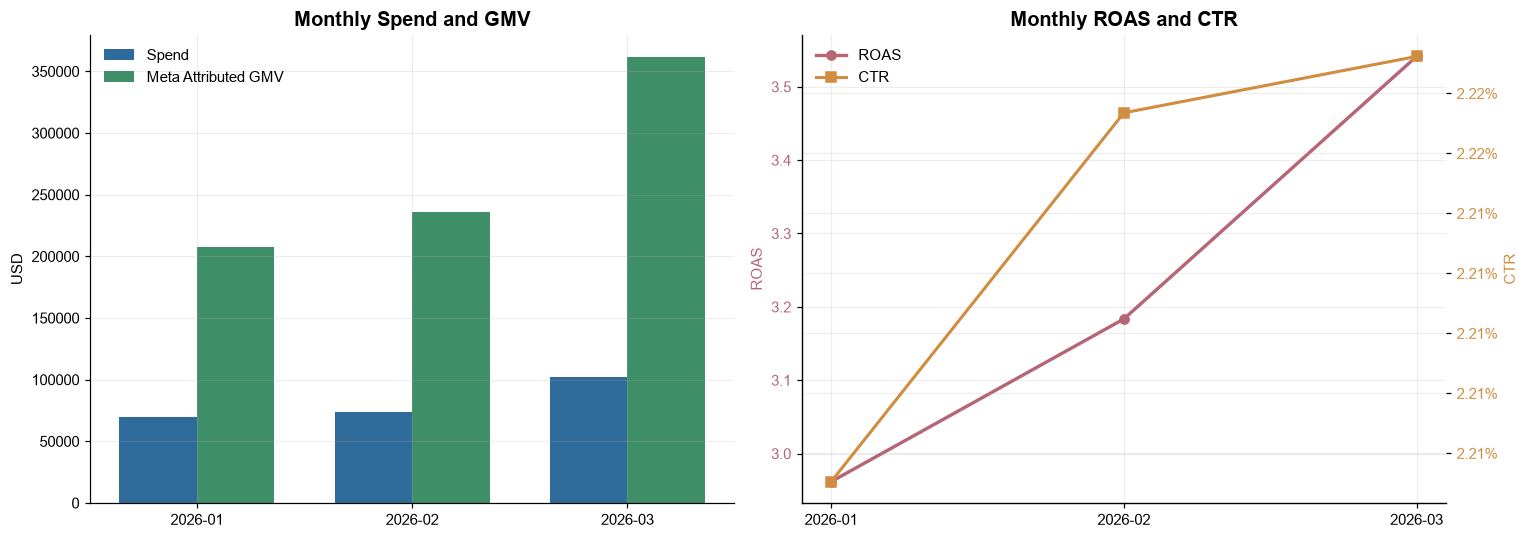

In [59]:
monthly = compute_metrics(df_analysis, "Month").sort_values("Month").reset_index(drop=True)
monthly["Spend_MoM"] = monthly["Spend"].pct_change()
monthly["GMV_MoM"] = monthly["GMV"].pct_change()
monthly["ROAS_MoM"] = monthly["ROAS"].pct_change()
monthly_display = monthly[[
    "Month", "Spend", "GMV", "ROAS", "CTR", "CPA", "Spend_MoM", "GMV_MoM", "ROAS_MoM"
]].copy()

display(monthly_display)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(monthly))
ax.bar(x - 0.18, monthly["Spend"], width=0.36, label="Spend", color=COLORS["spend"])
ax.bar(x + 0.18, monthly["GMV"], width=0.36, label="Meta Attributed GMV", color=COLORS["gmv"])
ax.set_xticks(x, monthly["Month"])
ax.set_title("Monthly Spend and GMV")
ax.set_ylabel("USD")
ax.legend(frameon=False)

ax2 = axes[1]
ax2.plot(x, monthly["ROAS"], marker="o", linewidth=2.2, color=COLORS["roas"], label="ROAS")
ax2.set_xticks(x, monthly["Month"])
ax2.set_ylabel("ROAS", color=COLORS["roas"])
ax2.tick_params(axis="y", labelcolor=COLORS["roas"])
ax2b = ax2.twinx()
ax2b.plot(x, monthly["CTR"], marker="s", linewidth=2.0, color=COLORS["ctr"], label="CTR")
ax2b.set_ylabel("CTR", color=COLORS["ctr"])
ax2b.tick_params(axis="y", labelcolor=COLORS["ctr"])
ax2b.yaxis.set_major_formatter(lambda v, _: f"{v:.2%}")
ax2.set_title("Monthly ROAS and CTR")
lines = ax2.get_lines() + ax2b.get_lines()
ax2.legend(lines, [line.get_label() for line in lines], frameon=False, loc="best")

plt.tight_layout()
plt.show()


,Week_Label,Week_Start,Week_End,Is_Partial_Week,Spend,GMV,ROAS,CTR,CPA
0,2026-W01,2026-01-01,2026-01-04,True,"9,211.490000","26,354.320000",2.861027,0.022388,27.829275
1,2026-W02,2026-01-05,2026-01-11,False,"15,553.580000","46,318.480000",2.977995,0.022202,26.862832
2,2026-W03,2026-01-12,2026-01-18,False,"15,922.320000","48,042.080000",3.017279,0.022230,26.493045
3,2026-W04,2026-01-19,2026-01-25,False,"15,788.350000","47,266.360000",2.993749,0.021952,26.579714
4,2026-W05,2026-01-26,2026-02-01,False,"16,341.450000","48,145.260000",2.946205,0.021648,26.833251
5,2026-W06,2026-02-02,2026-02-08,False,"18,159.330000","59,173.510000",3.258573,0.022412,24.673003
6,2026-W07,2026-02-09,2026-02-15,False,"18,557.680000","58,039.480000",3.127518,0.022126,25.317435
7,2026-W08,2026-02-16,2026-02-22,False,"18,694.630000","59,388.870000",3.176788,0.022205,24.992821
8,2026-W09,2026-02-23,2026-03-01,False,"19,384.190000","62,834.580000",3.241538,0.021824,24.630483
9,2026-W10,2026-03-02,2026-03-08,False,"22,913.960000","82,137.500000",3.584605,0.022256,22.530934


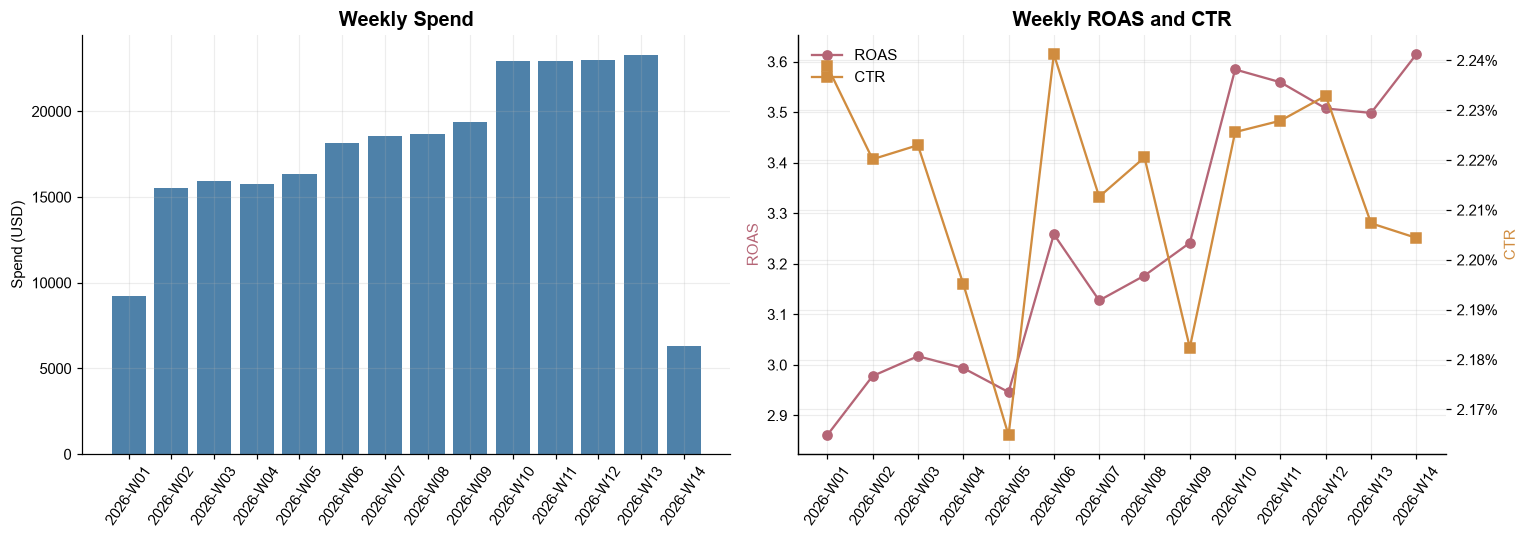

In [60]:
weekly = compute_metrics(df_analysis, "Week_Label").reset_index()
week_bounds = (
    df_analysis.groupby("Week_Label")
    .agg(Week_Start=("Date", "min"), Week_End=("Date", "max"), Rows=("Date", "size"))
    .reset_index()
)
weekly = week_bounds.merge(weekly, on="Week_Label", how="left").sort_values("Week_Label").reset_index(drop=True)
weekly["Is_Partial_Week"] = weekly["Rows"] < weekly["Rows"].max()

weekly_display = weekly[[
    "Week_Label", "Week_Start", "Week_End", "Is_Partial_Week",
    "Spend", "GMV", "ROAS", "CTR", "CPA"
]].copy()
display(weekly_display)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(weekly["Week_Label"], weekly["Spend"], color=COLORS["spend"], alpha=0.85)
ax.set_title("Weekly Spend")
ax.set_ylabel("Spend (USD)")
ax.tick_params(axis="x", rotation=55)

ax2 = axes[1]
ax2.plot(weekly["Week_Label"], weekly["ROAS"], marker="o", color=COLORS["roas"], label="ROAS")
ax2.set_ylabel("ROAS", color=COLORS["roas"])
ax2.tick_params(axis="x", rotation=55)
ax2b = ax2.twinx()
ax2b.plot(weekly["Week_Label"], weekly["CTR"], marker="s", color=COLORS["ctr"], label="CTR")
ax2b.set_ylabel("CTR", color=COLORS["ctr"])
ax2b.yaxis.set_major_formatter(lambda v, _: f"{v:.2%}")
ax2.set_title("Weekly ROAS and CTR")
lines = ax2.get_lines() + ax2b.get_lines()
ax2.legend(lines, [line.get_label() for line in lines], frameon=False, loc="best")

plt.tight_layout()
plt.show()


### 时间维度结论

1. **规模逐月扩张，效率同步改善。** 3 月 Spend 由 1 月的 $70,014 上升到 $102,023，GMV 由 $207,359 上升到 $361,295；ROAS 从 2.962 提升至 3.541，CPA 从 $26.90 下降至 $22.72。
2. **CTR 基本稳定。** 三个月 CTR 都约 2.20%，说明效率改善主要不是由点击率突变驱动，更可能来自国家/素材结构、转化承接与归因结果改善。
3. **W10 起出现明显的规模台阶。** 从 3 月第一周开始，周 Spend 由约 $19.4k 跃升到 $22.9k，同时 ROAS 提升到 3.50 以上。该现象值得结合预算调整、促销活动、受众结构或素材迭代记录进行复盘。
4. W01 和 W14 为不完整周，不能直接与完整周比较绝对规模；周度读取重点应放在完整周之间的变点。


### 4.2 国家维度：规模、ROAS 与获客成本

国家分析优先看三件事：

1. 该市场是否具备规模贡献，用 Spend Share 与 GMV Share 判断；
2. 该市场是否有效，用 ROAS 与 CPA 判断；
3. 该市场是“效率高但投入少”，还是“投入大但回报弱”。

平均 ROAS 不是边际 ROAS。预算加码后的下一美元收益可能低于当前 blended ROAS，因此结论应表述为“优先测试增量”，而不是承诺同比例扩张一定保持当前回报。


,Country,Spend,Spend_Share,GMV,GMV_Share,Contribution_Gap,ROAS,CTR,CPC,CPA,Purchases,AOV
0,AU,"33,844.100000",0.137527,"141,352.890000",0.175725,0.038198,4.176589,0.024262,0.574808,19.428301,1742,81.144024
1,US,"92,746.020000",0.376879,"330,735.830000",0.411160,0.034281,3.566038,0.023076,0.691825,23.829913,3892,84.978374
2,CA,"34,931.790000",0.141947,"110,200.760000",0.136998,-0.004949,3.154741,0.022028,0.618744,24.686777,1415,77.880396
3,FR,"24,056.410000",0.097755,"70,210.100000",0.087283,-0.010472,2.918561,0.020735,0.546389,24.749393,972,72.232613
4,UK,"34,636.820000",0.140749,"97,426.280000",0.121117,-0.019631,2.812795,0.021782,0.674078,27.166133,1275,76.412769
5,DE,"25,874.790000",0.105144,"54,470.940000",0.067717,-0.037427,2.105174,0.019152,0.634217,34.135607,758,71.861398


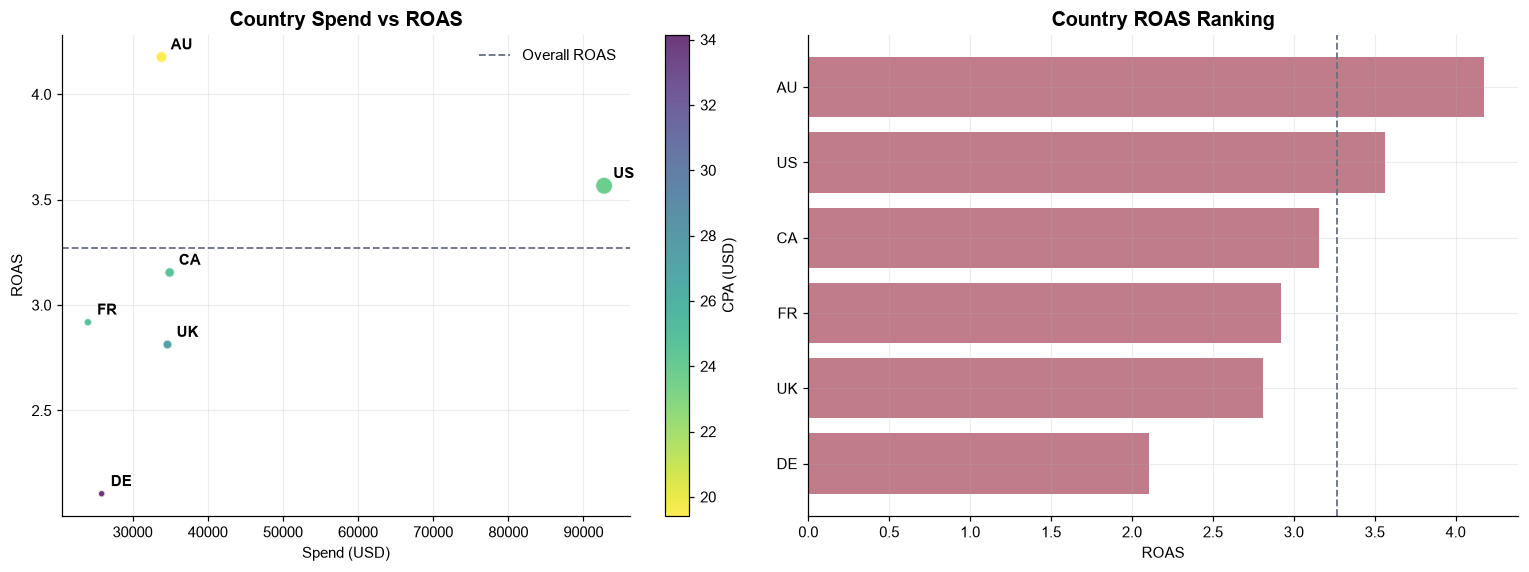

In [61]:
country = compute_metrics(df_analysis, "Country").sort_values("ROAS", ascending=False).reset_index(drop=True)
country["Spend_Share"] = country["Spend"] / country["Spend"].sum()
country["GMV_Share"] = country["GMV"] / country["GMV"].sum()
country["Contribution_Gap"] = country["GMV_Share"] - country["Spend_Share"]

country_display = country[[
    "Country", "Spend", "Spend_Share", "GMV", "GMV_Share", "Contribution_Gap",
    "ROAS", "CTR", "CPC", "CPA", "Purchases", "AOV"
]].copy()
display(country_display)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.3))

ax = axes[0]
scatter = ax.scatter(
    country["Spend"],
    country["ROAS"],
    s=country["GMV"] / 2500,
    c=country["CPA"],
    cmap="viridis_r",
    alpha=0.78,
    edgecolor="white",
    linewidth=1.2,
)
for _, row in country.iterrows():
    ax.annotate(
        row["Country"],
        (row["Spend"], row["ROAS"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontweight="bold",
    )
ax.axhline(overall.loc[0, "ROAS"], color=COLORS["neutral"], linestyle="--", linewidth=1.2, label="Overall ROAS")
ax.set_title("Country Spend vs ROAS")
ax.set_xlabel("Spend (USD)")
ax.set_ylabel("ROAS")
ax.legend(frameon=False)
fig.colorbar(scatter, ax=ax, label="CPA (USD)")

ax2 = axes[1]
country_plot = country.sort_values("ROAS")
ax2.barh(country_plot["Country"], country_plot["ROAS"], color=COLORS["roas"], alpha=0.85)
ax2.axvline(overall.loc[0, "ROAS"], color=COLORS["neutral"], linestyle="--", linewidth=1.2)
ax2.set_title("Country ROAS Ranking")
ax2.set_xlabel("ROAS")

plt.tight_layout()
plt.show()


### 国家维度结论

1. **AU 是最高效率市场。** ROAS 4.177、CPA $19.43，但 Spend Share 仅 13.8%，GMV Share 达 17.6%，贡献高于投入，适合优先做小步增量测试。
2. **US 是规模与效率兼顾的主力市场。** Spend Share 37.7%、GMV Share 41.1%、ROAS 3.566，是收入贡献最大的基本盘。加预算时应监控边际 ROAS 与频次，避免只按平均 ROAS 放大。
3. **DE 是 Q1 的主要效率短板。** ROAS 2.105、CPA $34.14，GMV Share 6.8% 低于 Spend Share 10.5%。应先拆解素材、受众与落地页，再决定削减预算，避免简单关停造成学习期损失。
4. **UK 与 CA 需要结构优化。** UK ROAS 2.813、CPA $27.17，CA ROAS 3.155、CPA $24.69；两者都具有规模，但效率低于整体。优先检查投放层级、版位与素材结构。
5. **FR 是效率尚可但规模较小的市场。** ROAS 2.919、CPA $24.75，且 Spend Share 仅 9.8%。可先做小幅预算测试，验证增量 ROAS 后再决定是否扩张。


### 4.3 素材维度：视频、轮播与静态图片

素材分析先对三类素材做统一描述，再把 Video 与 Static 放入后续 A/B 回测。Carousel 保留在完整素材复盘中，但不混入本次预先定义的 Video vs Static 检验。


,Creative_Type,Spend,Spend_Share,GMV,GMV_Share,ROAS,CTR,CPC,CPA,AOV,Purchases
0,Video,"112,805.300000",0.458391,"384,260.090000",0.477700,3.406401,0.022502,0.628004,23.432759,79.821373,4814
1,Carousel,"75,064.680000",0.305029,"240,115.430000",0.298504,3.198780,0.022105,0.640609,25.130459,80.386820,2987
2,Static,"58,219.950000",0.236580,"180,021.280000",0.223797,3.092089,0.021512,0.655608,25.841079,79.902921,2253


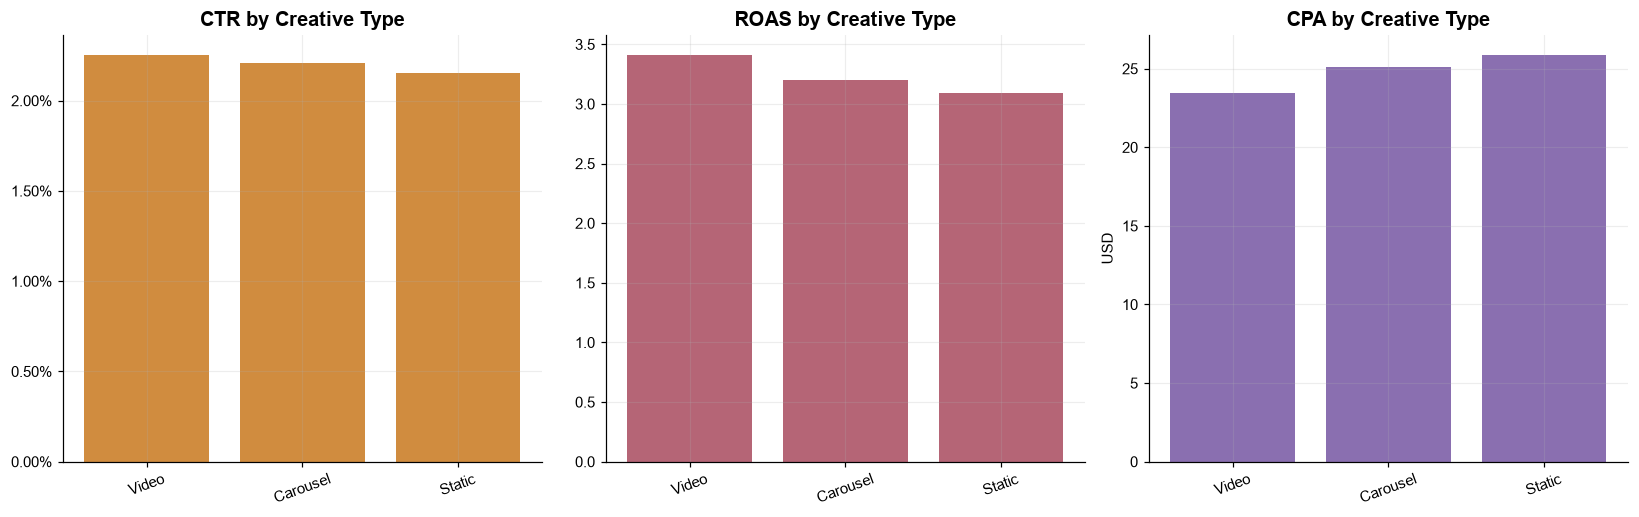

In [62]:
creative = compute_metrics(df_analysis, "Creative_Type").sort_values("ROAS", ascending=False).reset_index(drop=True)
creative["Spend_Share"] = creative["Spend"] / creative["Spend"].sum()
creative["GMV_Share"] = creative["GMV"] / creative["GMV"].sum()
creative_display = creative[[
    "Creative_Type", "Spend", "Spend_Share", "GMV", "GMV_Share",
    "ROAS", "CTR", "CPC", "CPA", "AOV", "Purchases"
]].copy()
display(creative_display)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
plot_data = creative.sort_values("ROAS", ascending=False)

axes[0].bar(plot_data["Creative_Type"], plot_data["CTR"], color=COLORS["ctr"])
axes[0].set_title("CTR by Creative Type")
axes[0].yaxis.set_major_formatter(lambda v, _: f"{v:.2%}")

axes[1].bar(plot_data["Creative_Type"], plot_data["ROAS"], color=COLORS["roas"])
axes[1].set_title("ROAS by Creative Type")

axes[2].bar(plot_data["Creative_Type"], plot_data["CPA"], color=COLORS["cpa"])
axes[2].set_title("CPA by Creative Type")
axes[2].set_ylabel("USD")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### 素材维度结论

1. Video 在三类素材中同时拥有最高的 ROAS（3.406）与 CTR（2.250%），CPA 也最低（$23.43）。
2. Static 的 ROAS 为 3.092、CTR 为 2.151%、CPA 为 $25.84，描述性结果弱于 Video。
3. Carousel 处于中间位置，ROAS 3.199、CTR 2.211%、CPA $25.13，不应被忽略；在商品多款式、多颜色展示场景中仍可能具备价值。
4. 素材差异需要进一步检验，但即使 CTR 显著，也不能直接把全部预算切给 Video。广告表现同时受国家、Campaign 类型、版位和受众影响。


## 五、用户全链路转化漏斗与流失诊断

本 Notebook 使用六个标准层级：

**曝光 -> 链接点击 -> 落地页访问 -> 加购 -> 发起结账 -> 购买**

每个阶段同时展示：

- 阶段总量；
- 相对上一层的转化率；
- 相对曝光量的整体留存率；
- 相对上一层的流失率。


,Stage,Value,Step_Conversion,Overall_Retention,Step_Dropoff
0,Impressions,17411655,1.000000,1.000000,NaN
1,Link Clicks,385605,0.022146,0.022146,0.977854
2,Landing Page Views,331770,0.860388,0.019054,0.139612
3,Add to Cart,32135,0.096859,0.001846,0.903141
4,Initiate Checkout,17472,0.543706,0.001003,0.456294
5,Purchases,10054,0.575435,0.000577,0.424565


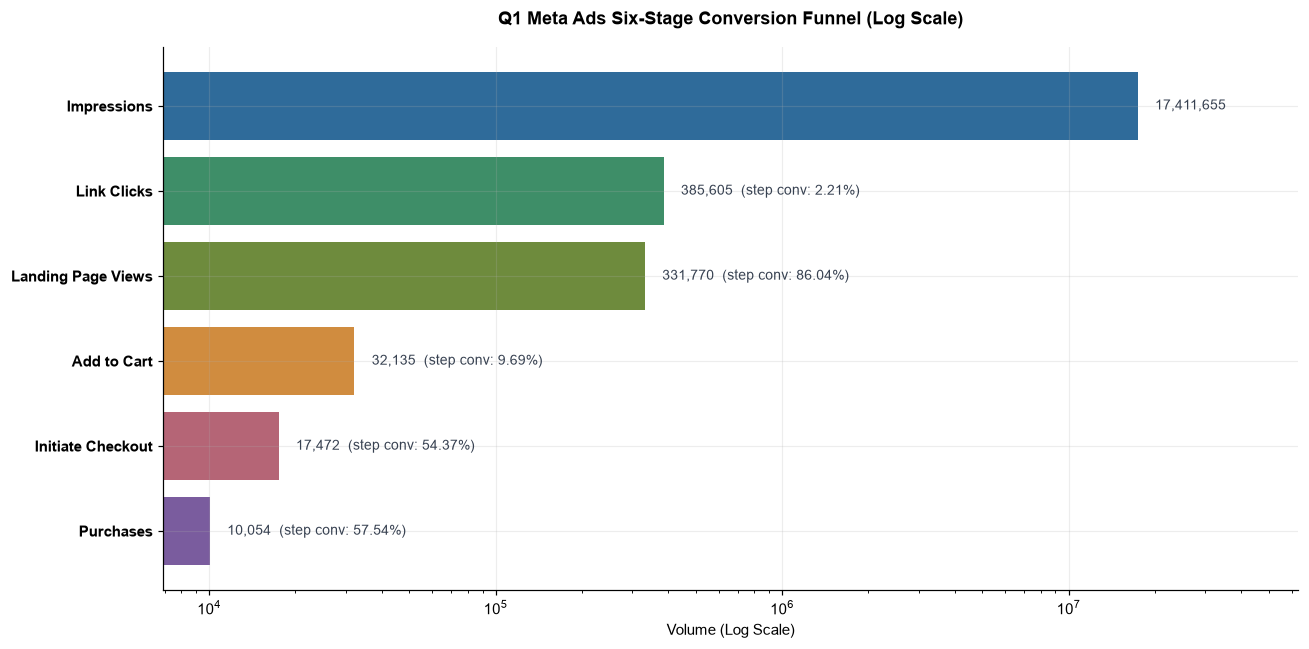

In [63]:
funnel_stages = [
    ("Impressions", "Impressions"),
    ("Link Clicks", "Link_Clicks"),
    ("Landing Page Views", "Landing_Page_Views"),
    ("Add to Cart", "Add_to_Cart"),
    ("Initiate Checkout", "Initiate_Checkout"),
    ("Purchases", "Purchases"),
]

funnel_values = []
for stage_name, col in funnel_stages:
    funnel_values.append({
        "Stage": stage_name,
        "Value": df_analysis[col].sum(),
    })

funnel = pd.DataFrame(funnel_values)
funnel["Step_Conversion"] = funnel["Value"] / funnel["Value"].shift(1)
funnel.loc[0, "Step_Conversion"] = 1.0
funnel["Overall_Retention"] = funnel["Value"] / funnel.loc[0, "Value"]
funnel["Step_Dropoff"] = 1 - funnel["Step_Conversion"]
funnel.loc[0, "Step_Dropoff"] = np.nan

display(funnel)

# 漏斗图代码片段
fig, ax = plt.subplots(figsize=(12, 6))
y = np.arange(len(funnel))
widths = funnel["Value"].to_numpy()
bars = ax.barh(y, widths, color=["#2F6B9A", "#3E8E68", "#6E8B3D", "#D08C3F", "#B56576", "#7A5C9E"])
ax.invert_yaxis()
ax.set_xscale('log') 
ax.set_title("Q1 Meta Ads Six-Stage Conversion Funnel (Log Scale)", fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Volume (Log Scale)", fontsize=10)

# 核心优化：直接把左侧的 0, 1, 2... 替换成各阶段的名称，省去 Y 轴空白
ax.set_yticks(y)
ax.set_yticklabels(funnel["Stage"], fontsize=10, fontweight='bold')

for i, (bar, row) in enumerate(zip(bars, funnel.itertuples(index=False))):
    # 将数值和转化率整合成两行清晰的文字写在柱子右侧
    label = f"{row.Value:,.0f}"
    if i > 0:
        label += f"  (step conv: {row.Step_Conversion:.2%})"
        
    ax.text(bar.get_width() * 1.15, bar.get_y() + bar.get_height() / 2,
            label, ha="left", va="center", color="#374151", fontsize=9)

# 稍微放大 X 轴右侧边界，给最长的 Impressions 标签留出空间
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax * 2.5)

plt.tight_layout()
plt.show()

### 漏斗流失诊断

1. **第一道可见流失发生在点击到落地页。** 落地页承接率为 86.04%，说明跨越点击后的页面加载与跳转链路总体稳定。
2. **最大转化瓶颈是落地页到加购。** 只有 9.69% 的落地页访问产生加购，绝对流失超过 29.9 万次访问。泳装品类通常会受到尺码不确定、版型适配、模特展示、真实买家秀、价格与退换货预期影响。
3. **加购到发起结账同样存在明显流失。** 加购到结账发起率为 54.37%，接近一半的加购用户在结算前退出，常见原因包括运费门槛、优惠预期、支付方式、配送时效与结账步骤复杂度。
4. **发起结账到购买率为 57.54%。** 该环节仍有 42.46% 的流失，不能简单判断“结账链路无问题”。支付失败、额外费用披露、信任与安全信息不足都可能造成流失。
5. **端到端购买率约为 0.058%。** 漏斗应从两端同时优化：前端继续提高点击质量，中后段重点修复 PDP、加购和结账承接。

> 一致性说明：120 条行级记录出现购买大于发起结账，但总量层面漏斗仍单调。若采用更保守的行级封顶口径，购买总量会由 10,054 降至 9,890，购买完成率由 57.54% 降至 56.60%。主分析保留 Meta 原始归因口径，并在业务复盘中标注这一敏感性。


## 六、创意素材 A/B 假设检验与决策建议

### 6.1 实验问题与假设

本模块比较 Video 与 Static 的链接点击率：

- 对照组 A：Static；
- 实验组 B：Video；
- 观测单位：一次曝光；
- 成功事件：产生一次 Link Click；
- 检验方法：两样本比例 Z 检验；
- 显著性水平：`alpha = 0.05`。

**原假设 H0：** `p_video = p_static`，视频与静态素材的真实 CTR 相同。  
**备择假设 H1：** `p_video > p_static`，视频素材的真实 CTR 更高。

市场判断采用单侧检验，因为业务问题具有明确方向。代码同时报告双侧 p 值，用于说明差异是否在任何方向上显著。

### 6.2 重要口径修正

旧逻辑把每条广告记录的 CTR 当作一个样本，并使用广告记录数量作为 `n`。这相当于给低曝光记录与高曝光记录相同权重，不符合比例检验的数据生成过程。

本版本使用：

`Static: x=总点击, n=总曝光`  
`Video: x=总点击, n=总曝光`

只有当每个广告记录会改变实际投放权重时，才应使用加权模型或在广告层做聚类稳健标准误；基础两样本比例检验应以曝光和点击的聚合计数为准。


Video vs Static 聚合表现


,Rows,Spend,Impressions,Clicks,GMV,Purchases,CTR,ROAS,CPA
Creative_Type,,,,,,,,,
Static,916,"58,219.950000",4128157,88803,"180,021.280000",2253,0.021512,3.092089,25.841079
Video,1719,"112,805.300000",7982578,179625,"384,260.090000",4814,0.022502,3.406401,23.432759


两样本比例 Z 检验


,指标,结果
0,Static CTR,2.151%
1,Video CTR,2.250%
2,绝对差异（百分点）,0.0991 pp
3,相对提升,4.605%
4,Z 统计量,11.0994
5,单侧 P 值,6.317e-29
6,双侧 P 值,1.263e-28
7,差异 95% CI 下限（百分点）,0.0817 pp
8,差异 95% CI 上限（百分点）,0.1164 pp
9,alpha,0.05


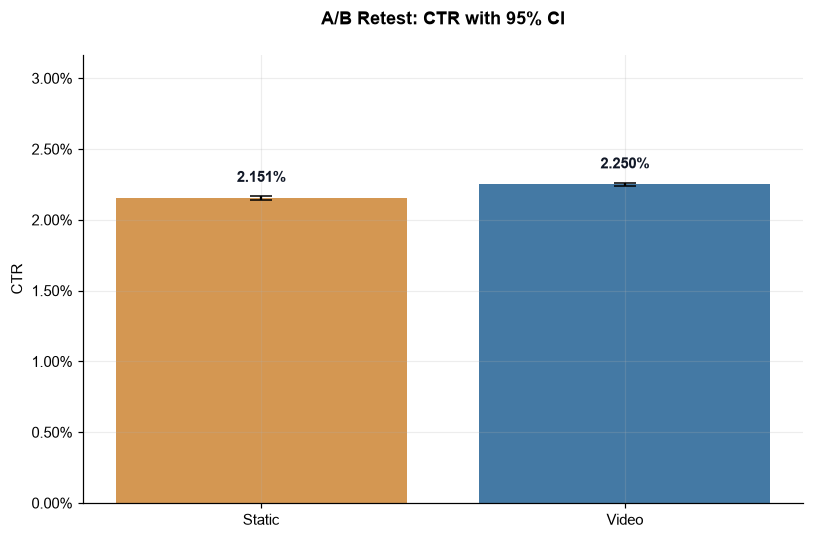

统计显著性对应的业务量级示意（非因果承诺）


,示意项,结果
0,Static 当前曝光,"4,128,157"
1,CTR 差额,0.0991 pp
2,预计增量点击,"4,089"
3,按全局点击到购买率推算的增量购买,106.6
4,按全局 AOV 推算的增量归因 GMV,"$8,530.59"


In [64]:
df_ab = df_analysis[df_analysis["Creative_Type"].isin(["Static", "Video"])].copy()

ab_counts = (
    df_ab.groupby("Creative_Type", dropna=False)
    .agg(
        Rows=("Creative_Type", "size"),
        Spend=("Spend_USD", "sum"),
        Impressions=("Impressions", "sum"),
        Clicks=("Link_Clicks", "sum"),
        GMV=("Meta_Attributed_GMV_USD", "sum"),
        Purchases=("Purchases", "sum"),
    )
    .reindex(["Static", "Video"])
)
ab_counts["CTR"] = ab_counts["Clicks"] / ab_counts["Impressions"]
ab_counts["ROAS"] = ab_counts["GMV"] / ab_counts["Spend"]
ab_counts["CPA"] = ab_counts["Spend"] / ab_counts["Purchases"]

x_static = ab_counts.loc["Static", "Clicks"]
n_static = ab_counts.loc["Static", "Impressions"]
x_video = ab_counts.loc["Video", "Clicks"]
n_video = ab_counts.loc["Video", "Impressions"]

p_static = x_static / n_static
p_video = x_video / n_video
p_pool = (x_static + x_video) / (n_static + n_video)

se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n_static + 1 / n_video))
z_stat = (p_video - p_static) / se_pool
p_one_sided = norm.sf(z_stat)
p_two_sided = 2 * norm.sf(abs(z_stat))

se_unpooled = np.sqrt(
    p_static * (1 - p_static) / n_static
    + p_video * (1 - p_video) / n_video
)
z_critical = norm.ppf(0.975)
diff = p_video - p_static
ci_low = diff - z_critical * se_unpooled
ci_high = diff + z_critical * se_unpooled
relative_lift = diff / p_static

ab_result = pd.DataFrame({
    "指标": [
        "Static CTR",
        "Video CTR",
        "绝对差异（百分点）",
        "相对提升",
        "Z 统计量",
        "单侧 P 值",
        "双侧 P 值",
        "差异 95% CI 下限（百分点）",
        "差异 95% CI 上限（百分点）",
        "alpha",
        "结论",
    ],
    "结果": [
        fmt_pct(p_static),
        fmt_pct(p_video),
        f"{diff * 100:.4f} pp",
        fmt_pct(relative_lift),
        f"{z_stat:.4f}",
        f"{p_one_sided:.3e}",
        f"{p_two_sided:.3e}",
        f"{ci_low * 100:.4f} pp",
        f"{ci_high * 100:.4f} pp",
        "0.05",
        "拒绝 H0：Video CTR 显著高于 Static" if p_one_sided < 0.05 else "不能拒绝 H0",
    ],
})

print("Video vs Static 聚合表现")
display(ab_counts)
print("两样本比例 Z 检验")
display(ab_result)


ctr_se = np.sqrt(ab_counts["CTR"] * (1 - ab_counts["CTR"]) / ab_counts["Impressions"])

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(
    ab_counts.index,
    ab_counts["CTR"],
    yerr=z_critical * ctr_se,
    capsize=7,
    color=[COLORS["static"], COLORS["video"]],
    alpha=0.9,
)

# 1. 扩宽 Y 轴上限，确保顶部有足够空间
max_y = (ab_counts["CTR"] + z_critical * ctr_se).max()
ax.set_ylim(0, max_y * 1.4)

# 2. 遍历添加数值标签，用更稳妥的绝对偏移量
for bar, value, se in zip(bars, ab_counts["CTR"], ctr_se):
    # 标签位置 = 柱子高度 + 误差线高度 + 一个固定的安全间距 (0.0008 约等于 0.08%)
    y_pos = value + (z_critical * se) + 0.0008
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        y_pos, 
        f"{value:.3%}", 
        ha="center", 
        va="bottom", 
        fontweight="bold",
        fontsize=10,
        color="#111827"
    )

# 3. 规范标题和 Y 轴格式
ax.set_title("A/B Retest: CTR with 95% CI", fontsize=12, fontweight='bold', pad=20)
ax.set_ylabel("CTR", fontsize=10)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.2%}")

plt.tight_layout()
plt.show()


# 业务量级示意：在“下游转化率不变”的假设下，若 Static 曝光达到 Video 的 CTR，预计增加多少点击。
incremental_clicks = n_static * diff
click_to_purchase = overall.loc[0, "Purchases"] / overall.loc[0, "Link_Clicks"]
aov = overall.loc[0, "AOV"]
incremental_purchases = incremental_clicks * click_to_purchase
incremental_gmv = incremental_purchases * aov

business_impact = pd.DataFrame({
    "示意项": [
        "Static 当前曝光",
        "CTR 差额",
        "预计增量点击",
        "按全局点击到购买率推算的增量购买",
        "按全局 AOV 推算的增量归因 GMV",
    ],
    "结果": [
        f"{n_static:,.0f}",
        f"{diff * 100:.4f} pp",
        f"{incremental_clicks:,.0f}",
        f"{incremental_purchases:,.1f}",
        fmt_money(incremental_gmv),
    ],
})

print("统计显著性对应的业务量级示意（非因果承诺）")
display(business_impact)


Campaign Type 分层敏感性检查


,Campaign_Type,Static_CTR,Video_CTR,Difference_pp,One_Sided_P,Video_Higher
0,Prospecting_Broad,0.018409,0.019480,0.107068,0.000000,True
1,Prospecting_Lookalike_1pct,0.022764,0.023269,0.050512,0.010618,True
2,Prospecting_Interest_Beachwear,0.017721,0.017700,-0.002061,0.537752,False
3,Retargeting_7D_ATCVC,0.031549,0.030876,-0.067332,0.996646,False


Country 分层敏感性检查


,Country,Static_CTR,Video_CTR,Difference_pp,One_Sided_P,Video_Higher
0,DE,0.018221,0.019544,0.132280,0.000000,True
1,US,0.022247,0.023503,0.125557,0.000000,True
2,UK,0.021032,0.022167,0.113493,0.000001,True
3,FR,0.020184,0.021004,0.081998,0.000592,True
4,CA,0.021534,0.022237,0.070271,0.001235,True
5,AU,0.024416,0.024385,-0.003105,0.550228,False


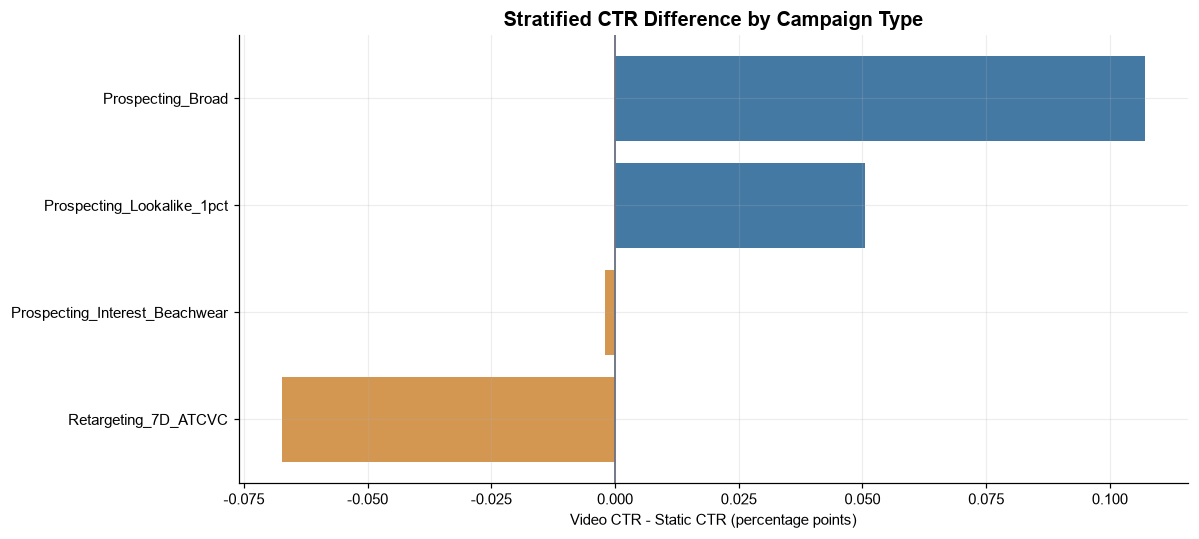

In [65]:
def stratified_ctr_test(data, dimension):
    rows = []
    for key, group in data.groupby(dimension, dropna=False):
        counts = (
            group.groupby("Creative_Type", dropna=False)
            .agg(Impressions=("Impressions", "sum"), Clicks=("Link_Clicks", "sum"))
            .reindex(["Static", "Video"])
        )
        if counts["Impressions"].isna().any() or (counts["Impressions"] <= 0).any():
            continue

        p_s = counts.loc["Static", "Clicks"] / counts.loc["Static", "Impressions"]
        p_v = counts.loc["Video", "Clicks"] / counts.loc["Video", "Impressions"]
        n_s = counts.loc["Static", "Impressions"]
        n_v = counts.loc["Video", "Impressions"]
        p_pool = (counts.loc["Static", "Clicks"] + counts.loc["Video", "Clicks"]) / (n_s + n_v)
        se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_s + 1 / n_v))

        if se == 0:
            z = 0.0
            pvalue = 1.0
        else:
            z = (p_v - p_s) / se
            pvalue = norm.sf(z)

        rows.append({
            dimension: key,
            "Static_CTR": p_s,
            "Video_CTR": p_v,
            "Difference_pp": (p_v - p_s) * 100,
            "One_Sided_P": pvalue,
            "Video_Higher": p_v > p_s,
        })

    return pd.DataFrame(rows)


strat_campaign = stratified_ctr_test(df_ab, "Campaign_Type").sort_values("Difference_pp", ascending=False).reset_index(drop=True)
strat_country = stratified_ctr_test(df_ab, "Country").sort_values("Difference_pp", ascending=False).reset_index(drop=True)

print("Campaign Type 分层敏感性检查")
display(strat_campaign)
print("Country 分层敏感性检查")
display(strat_country)

# 可视化各 Campaign Type 的 Video - Static CTR 差值。
fig, ax = plt.subplots(figsize=(11, 5))
colors = [COLORS["video"] if v > 0 else COLORS["static"] for v in strat_campaign["Difference_pp"]]
ax.barh(strat_campaign["Campaign_Type"], strat_campaign["Difference_pp"], color=colors, alpha=0.9)
ax.axvline(0, color=COLORS["neutral"], linewidth=1.2)
ax.set_title("Stratified CTR Difference by Campaign Type")
ax.set_xlabel("Video CTR - Static CTR (percentage points)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### A/B 回测结论与业务解释

1. **统计结论：拒绝 H0。** Video 聚合 CTR 为 2.250%，Static 为 2.152%，绝对差 0.0991 个百分点，相对提升 4.60%。池化比例 Z 检验结果约为 `Z = 11.10`、单侧 `P = 6.32e-29`，远低于 `alpha = 0.05`，95% CI 为 `[0.0817 pp, 0.1164 pp]`。
2. **统计显著不等于效果巨大。** 由于曝光量超过 1,200 万次，极小的 CTR 差异也会显著。业务上应同时看相对提升、增量点击、后续购买率与边际利润，而不是只按 p 值决策。
3. **分层结果并不完全一致。** Prospecting_Broad、Prospecting_Lookalike 与多数国家中 Video 的 CTR 更高，但 AU 出现极小负差，Retargeting_7D_ATCVC 与 Prospecting_Interest_Beachwear 也出现 Video 略低或持平。这说明整体优势可能混入国家、Campaign 类型和受众结构差异。
4. **这是历史数据回测，不是随机 A/B 实验。** 无法完全排除预算分配、受众、时间与版位等混杂变量。严格因果结论需要随机分流、同受众同预算同版位的线上实验。
5. **预算建议应更精细。** 在 Prospecting 场景优先增加 Video 创意测试比重，在 Retargeting 与特定国家保留 Static 作为对照，并设置最小业务提升阈值，例如相对 CTR 提升至少 2% 且增量贡献毛利为正，再进行规模化。


## 七、总结与业务优化建议

### 7.1 业务结论

1. Q1 共花费 $246,089.93，获得 $804,396.80 Meta 归因 GMV，整体 ROAS 3.269，CTR 2.215%，CPA $24.48。
2. 3 月规模与效率同步改善，ROAS 达到季度最高 3.541，CPA 降至季度最低 $22.72。
3. AU 的效率最高，US 的规模与贡献最大；DE 的 ROAS 最低且 CPA 最高，是主要效率问题市场。
4. Video 在三类素材中 CTR、ROAS、CPA 综合表现最好；Static 仍可承担特定场景的对照与稳定投放角色。
5. 漏斗最大流失点在落地页到加购，其次为加购到发起结账和发起结账到购买。报告不能把问题简化为单一环节。

### 7.2 预算与投放建议

| 优先级 | 业务动作 | 判断依据 | 验证方式 |
| --- | --- | --- | --- |
| P0 | AU 做 10% - 20% 的小步增量测试 | ROAS 4.177、CPA $19.43、贡献高于投入 | 观察边际 ROAS、频次、CPA 是否快速恶化 |
| P0 | US 保持主力并做分层放量 | 收入贡献最大，ROAS 3.566 | 分 Campaign/受众设置增量护栏 |
| P1 | DE 先做素材与 PDP 修复，再决定减量 | ROAS 2.105、CPA $34.14 | 对 Video/Static、受众和落地页做对照测试 |
| P1 | UK、CA 优化结构与素材 | 规模已具备但低于整体效率 | 检查版位、Campaign 类型和素材疲劳 |
| P1 | Video 在 Prospecting 中优先测试 | CTR 显著更高，ROAS 也更高 | 随机分流 A/B，设置最小业务提升阈值 |
| P1 | Retargeting 与异常国家保留 Static 对照 | 分层结果不一致 | 不按整体结论一刀切停投 Static |
| P0 | 优化 PDP：尺码、版型、买家秀、退换货 | 落地页到加购仅 9.69% | 用页面热图、问卷和站点漏斗验证 |
| P1 | 优化结算：运费门槛、支付、信任信息 | 加购到结账 54.37%、结账到购买 57.54% | 分步骤埋点与结账放弃回访实验 |
| P2 | 建立增量实验与边际 ROAS 看板 | 历史 ROAS 无法直接推断下一美元收益 | 预算阶梯测试、geo holdout、随机实验 |

### 7.3 数据与口径建议

1. 保留零购买记录，并在月度复盘中对 ROAS、CPA 同时报告；删除负样本会系统性高估效率。
2. 统一以聚合总量重算比率指标，避免“整体按总量、分层按行平均”的口径冲突。
3. 对行级购买大于发起结账的记录增加归因时点说明，并持续监控 Meta 归因与站内订单的一致性。
4. 增加毛利、退款、物流、优惠与新客 LTV 后，才能从 ROAS 判断真实利润。
5. 将“历史 CTR 回测”与“随机 A/B 实验”分开呈现：前者用于提出假设，后者用于因果决策。


In [66]:
# 基于当前数据生成可复用的业务行动清单。
overall_roas = overall.loc[0, "ROAS"]

def country_action(row):
    if row["ROAS"] >= overall_roas * 1.10:
        return "优先测试增量"
    if row["ROAS"] >= overall_roas:
        return "保持主力并分层放量"
    if row["ROAS"] >= 2.5:
        return "优化素材与落地页"
    return "控制预算并排查结构"

country_actions = country.copy()
country_actions["Action"] = country_actions.apply(country_action, axis=1)
country_actions = country_actions[[
    "Country", "Spend", "GMV", "ROAS", "CTR", "CPA", "Contribution_Gap", "Action"
]].sort_values("ROAS", ascending=False).reset_index(drop=True)

creative_action_map = {
    "Video": "优先测试并增加 Prospecting 创意占比",
    "Carousel": "保留多款式展示场景，继续观察",
    "Static": "保留 Retargeting/对照场景，逐步优化新增占比",
}
creative_actions = creative.copy()
creative_actions["Action"] = creative_actions["Creative_Type"].map(creative_action_map)
creative_actions = creative_actions[["Creative_Type", "ROAS", "CTR", "CPA", "Action"]]

funnel_action_rows = [
    ("Landing Page Views -> Add to Cart", "P0", "尺码、版型、买家秀、退换货承诺与 PDP 信息架构"),
    ("Add to Cart -> Initiate Checkout", "P0", "运费门槛、优惠表达、支付方式与结算步骤"),
    ("Initiate Checkout -> Purchases", "P1", "支付失败监控、信任信息、费用透明与放弃回访"),
    ("Link Clicks -> Landing Page Views", "P2", "维持落地页稳定性，并持续监测加载速度"),
]
funnel_actions = pd.DataFrame(funnel_action_rows, columns=["漏斗环节", "优先级", "建议动作"])

print("国家行动清单")
display(country_actions)
print("素材行动清单")
display(creative_actions)
print("漏斗行动清单")
display(funnel_actions)


国家行动清单


,Country,Spend,GMV,ROAS,CTR,CPA,Contribution_Gap,Action
0,AU,"33,844.100000","141,352.890000",4.176589,0.024262,19.428301,0.038198,优先测试增量
1,US,"92,746.020000","330,735.830000",3.566038,0.023076,23.829913,0.034281,保持主力并分层放量
2,CA,"34,931.790000","110,200.760000",3.154741,0.022028,24.686777,-0.004949,优化素材与落地页
3,FR,"24,056.410000","70,210.100000",2.918561,0.020735,24.749393,-0.010472,优化素材与落地页
4,UK,"34,636.820000","97,426.280000",2.812795,0.021782,27.166133,-0.019631,优化素材与落地页
5,DE,"25,874.790000","54,470.940000",2.105174,0.019152,34.135607,-0.037427,控制预算并排查结构


素材行动清单


,Creative_Type,ROAS,CTR,CPA,Action
0,Video,3.406401,0.022502,23.432759,优先测试并增加 Prospecting 创意占比
1,Carousel,3.198780,0.022105,25.130459,保留多款式展示场景，继续观察
2,Static,3.092089,0.021512,25.841079,保留 Retargeting/对照场景，逐步优化新增占比


漏斗行动清单


,漏斗环节,优先级,建议动作
0,Landing Page Views -> Add to Cart,P0,尺码、版型、买家秀、退换货承诺与 PDP 信息架构
1,Add to Cart -> Initiate Checkout,P0,运费门槛、优惠表达、支付方式与结算步骤
2,Initiate Checkout -> Purchases,P1,支付失败监控、信任信息、费用透明与放弃回访
3,Link Clicks -> Landing Page Views,P2,维持落地页稳定性，并持续监测加载速度


## 八、修改亮点说明

1. **修复选择性偏差。** 不再删除零购买、零 GMV 的 192 条记录，整体 ROAS、CPA 与漏斗口径回到真实投放样本。
2. **统一全套指标口径。** Spend、GMV、ROAS、CTR、CPC、CPA、AOV 与六层漏斗率均由同一个聚合函数计算，并校验原始字段。
3. **补全时间、国家、素材三维分析。** 月度与周度同步观察规模、ROAS、CTR、CPA；国家维度加入 Spend/GMV Share 与贡献差；素材维度覆盖 Video、Carousel、Static。
4. **升级六层漏斗。** 每层同时展示总量、阶段转化率、整体留存和流失率，并明确落地页到加购、加购到结账、结账到购买三个关键漏点。
5. **重写 A/B 检验。** 由“逐条广告 CTR 的伪样本”改为“总点击 / 总曝光”的两样本比例 Z 检验，明确 H0、H1、alpha、单侧/双侧 p 值、置信区间与业务量级示意。
6. **增加分层敏感性检查。** 发现 Video 的整体 CTR 优势在 Retargeting 与部分国家并不完全一致，避免一刀切停投 Static。
7. **区分统计显著与业务显著。** 在千万级曝光下，0.099 个百分点的差异也会显著，因此同时给出相对提升、增量点击和后续购买换算，并保持非因果表述。
8. **报告结构专业化。** 全文按项目背景、数据质量、指标定义、多维复盘、漏斗诊断、A/B 检验、业务建议、局限说明组织，适合作品集与求职展示。
